In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch import arch_model
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import sys
import os
sys.path.append(os.path.abspath('..'))
from data.yfinance_data import fetch_data
from config import TRAIN_END, EVAL_START, EVAL_END

In [2]:
data = fetch_data()

[*********************100%***********************]  1 of 1 completed


In [3]:
prices = data['Adj Close']
returns = np.log(prices/prices.shift(1)).dropna()
log_returns = returns * 100
log_returns.columns = ['Log Percentage Returns']

In [4]:
log_returns.head()

,Log Percentage Returns
Date,
2000-01-04,-3.909918
2000-01-05,0.192034
2000-01-06,0.095522
2000-01-07,2.672995
2000-01-10,1.112782


In [5]:
train_data = log_returns[:TRAIN_END]
eval_data = log_returns[EVAL_START:EVAL_END]

In [6]:
eval_data

,Log Percentage Returns
Date,
2013-01-02,2.508612
2013-01-03,-0.208780
2013-01-04,0.485330
2013-01-07,-0.312800
2013-01-08,-0.324764
...,...
2025-12-23,0.454007
2025-12-24,0.321630
2025-12-26,-0.030441


In [7]:
log_returns.iloc[:,0].mean()

np.float64(0.0238002034222972)

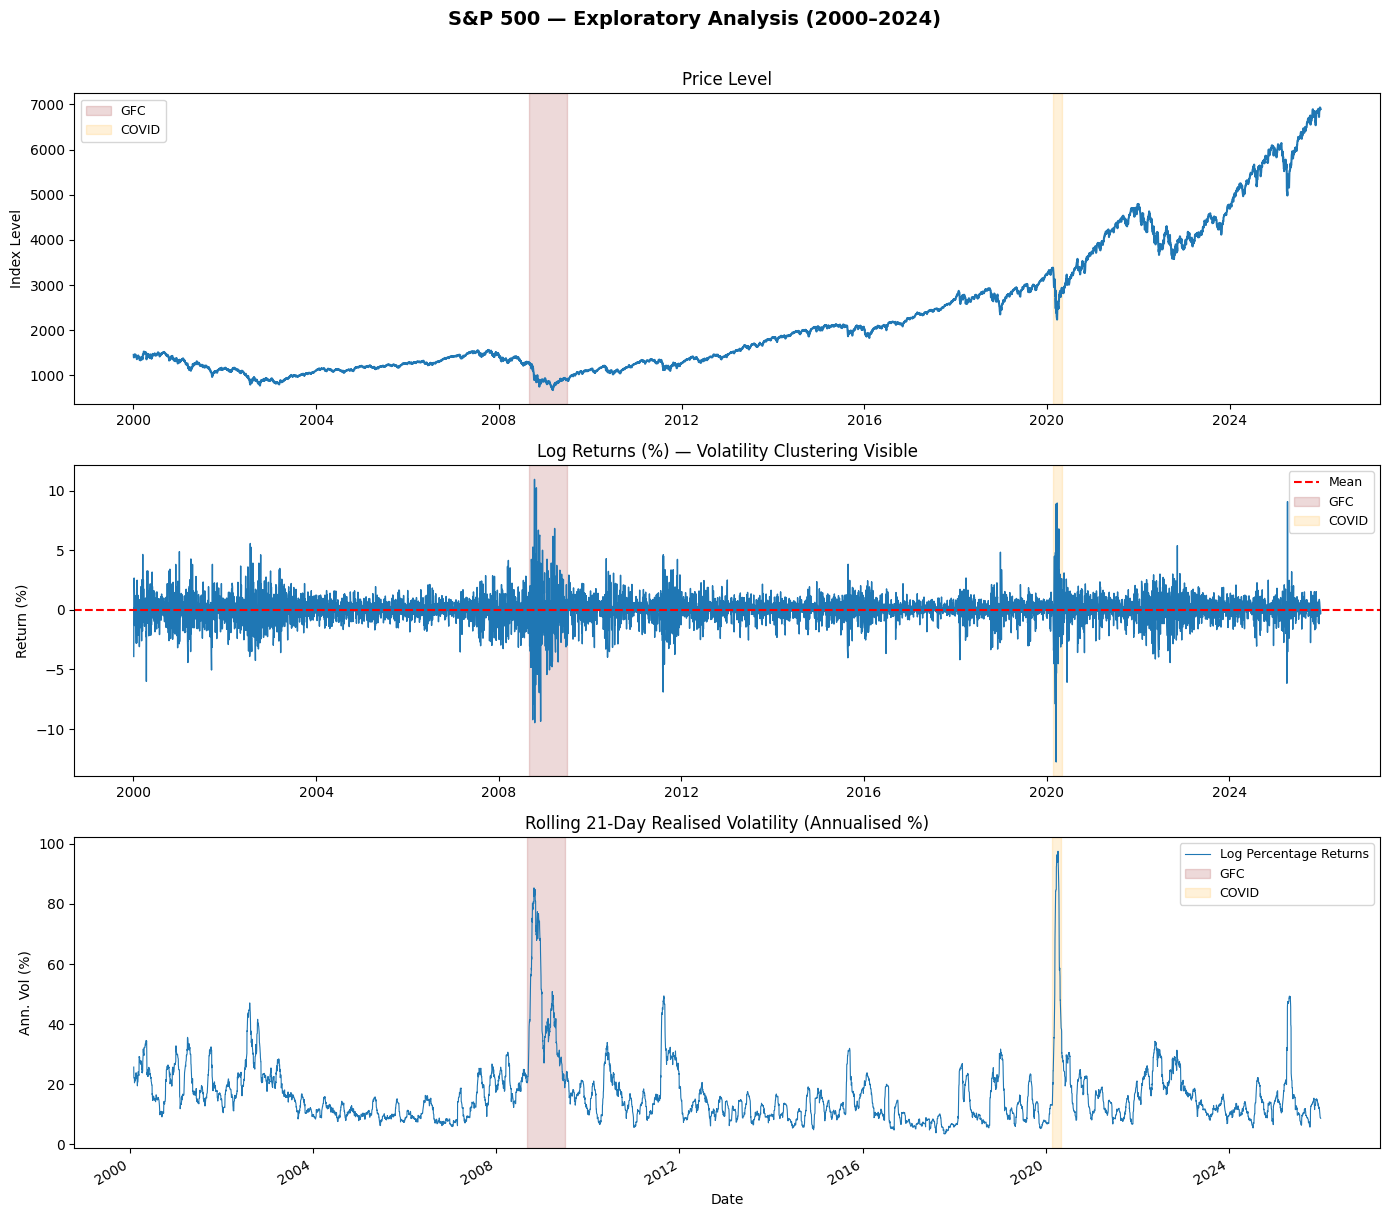

In [8]:
fig, axes = plt.subplots(3,1, figsize=(14,12))
fig.suptitle('S&P 500 — Exploratory Analysis (2000–2024)', fontsize=14, fontweight='bold', y=1.01)

ax = axes[0]
ax.plot(prices.index, prices.iloc[:,0])
ax.set_title('Price Level')
ax.set_ylabel('Index Level')
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'),
           alpha=0.15, color='darkred', label='GFC')
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'),
           alpha=0.15, color='orange', label='COVID')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(log_returns.index, log_returns.iloc[:,0], linewidth=1)
ax.set_title('Log Returns (%) — Volatility Clustering Visible')
ax.set_ylabel('Return (%)')
ax.axhline(log_returns.iloc[:,0].mean(), color='red', linestyle='--', label='Mean')
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'),
           alpha=0.15, color='darkred', label='GFC')
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'),
           alpha=0.15, color='orange', label='COVID')
ax.legend(fontsize=9)

ax = axes[2]
rv = log_returns.rolling(21).std() * np.sqrt(252)
rv.plot(ax=ax, linewidth=0.8)
ax.set_title('Rolling 21-Day Realised Volatility (Annualised %)')
ax.set_ylabel('Ann. Vol (%)')
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'),
           alpha=0.15, color='darkred', label='GFC')
ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'),
           alpha=0.15, color="orange", label='COVID')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


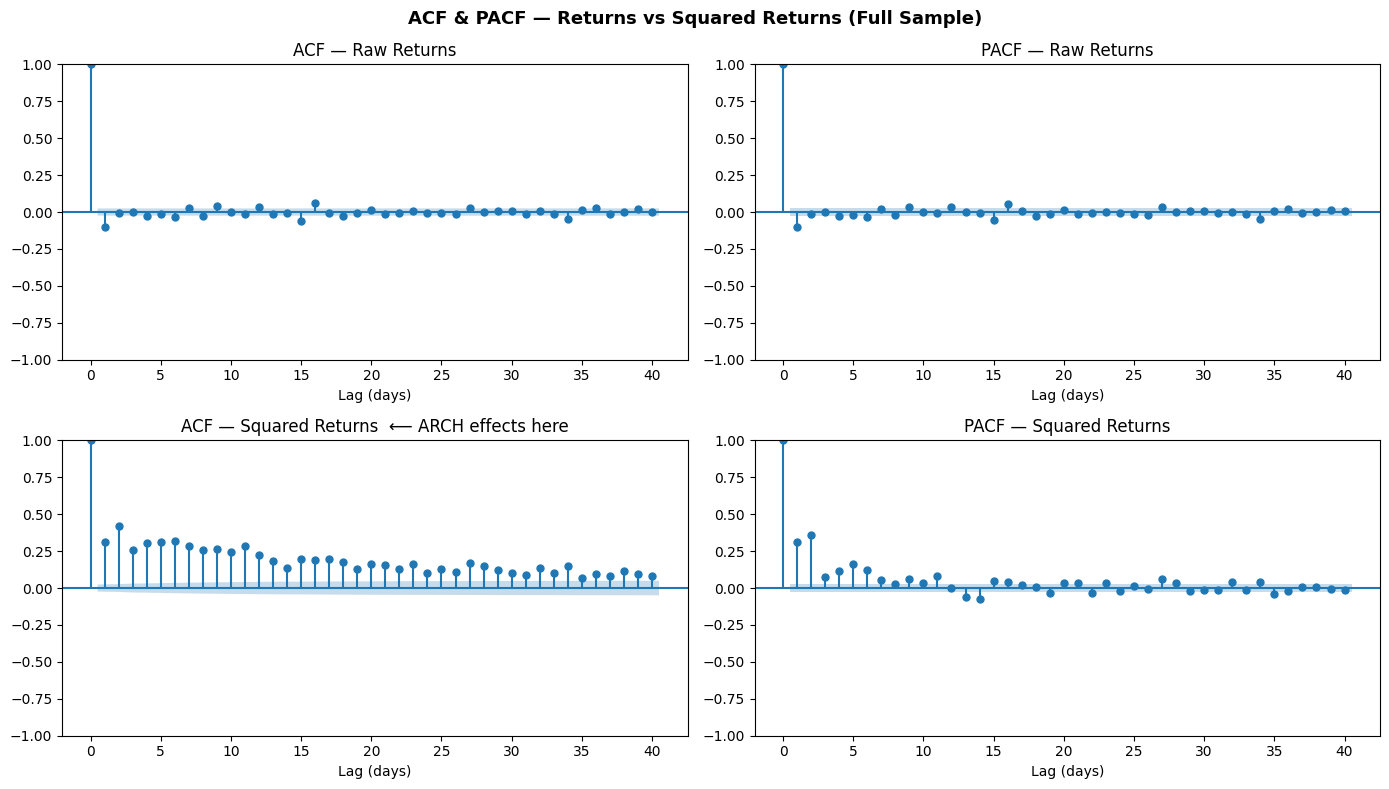

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ACF & PACF — Returns vs Squared Returns (Full Sample)', fontsize=13, fontweight='bold')

lags = 40

# Raw returns ACF
plot_acf(log_returns, lags=lags, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF — Raw Returns')
axes[0, 0].set_xlabel('Lag (days)')

# Raw returns PACF
plot_pacf(log_returns, lags=lags, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title('PACF — Raw Returns')
axes[0, 1].set_xlabel('Lag (days)')

# Squared returns ACF  ← This is where ARCH effects live
plot_acf(log_returns**2, lags=lags, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title('ACF — Squared Returns  ⟵ ARCH effects here')
axes[1, 0].set_xlabel('Lag (days)')

# Squared returns PACF
plot_pacf(returns**2, lags=lags, ax=axes[1, 1], alpha=0.05, method='ywm')
axes[1, 1].set_title('PACF — Squared Returns')
axes[1, 1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

In [10]:
from arch.unitroot import ADF
from statsmodels.stats.diagnostic import het_arch

demeaned = log_returns - log_returns.mean()

lm_stat, lm_pval, f_stat, f_pval = het_arch(demeaned, nlags=5)

In [11]:
print('=' * 55)
print("  Engle's ARCH LM Test (H₀: No ARCH effects)")
print('=' * 55)
print(f'  LM Statistic : {lm_stat:.4f}')
print(f'  LM p-value   : {lm_pval:.2e}')
print(f'  F Statistic  : {f_stat:.4f}')
print(f'  F p-value    : {f_pval:.2e}')
print('=' * 55)
print(f'  Decision     : {"Reject H₀ → ARCH effects confirmed" if lm_pval < 0.05 else "Fail to reject H₀"}')
print()
print('GARCH modelling is statistically justified.')

  Engle's ARCH LM Test (H₀: No ARCH effects)
  LM Statistic : 1640.2064
  LM p-value   : 0.00e+00
  F Statistic  : 437.6304
  F p-value    : 0.00e+00
  Decision     : Reject H₀ → ARCH effects confirmed

GARCH modelling is statistically justified.


In [17]:
def fit_garch(returns, vol = 'Garch', dist = 'normal', p=1, q=1, o=None, verbose=True):

    if o is None:

        model = arch_model(
            returns,
            vol = vol,
            p=1,
            q=1,
            dist=dist,
            mean='Constant',
            rescale=False
        )

    else:

        model = arch_model(
            returns,
            vol = vol,
            p=1,
            q=1,
            o=o,
            dist=dist,
            mean='Constant',
            rescale=False
        )

    result = model.fit(
        disp='off',
        options={'maxiter': 500}
    )
    return result

In [15]:
params = garch_train.params
mu    = params['mu']
omega = params['omega']
alpha = params['alpha[1]']
beta  = params['beta[1]']
persistence = alpha + beta
unconditional_var = omega / (1 - persistence)
unconditional_vol = np.sqrt(unconditional_var) * np.sqrt(252)  # Annualised

print('=' * 55)
print('  GARCH(1,1) Parameter Estimates — Training Window')
print('=' * 55)
print(f'  mu (mean)          : {mu:.6f}')
print(f'  omega (baseline)   : {omega:.6f}')
print(f'  alpha (ARCH term)  : {alpha:.6f}  ← shock sensitivity')
print(f'  beta  (GARCH term) : {beta:.6f}  ← vol persistence')
print(f'  alpha + beta       : {persistence:.6f}  ← total persistence')
print(f'  Stationary?        : {"Yes" if persistence < 1 else "No — IGARCH"}')
print(f'  Unconditional vol  : {unconditional_vol:.2f}% (annualised)')
print('=' * 55)

  GARCH(1,1) Parameter Estimates — Training Window
  mu (mean)          : 0.041392
  omega (baseline)   : 0.015468
  alpha (ARCH term)  : 0.086825  ← shock sensitivity
  beta  (GARCH term) : 0.903514  ← vol persistence
  alpha + beta       : 0.990339  ← total persistence
  Stationary?        : Yes
  Unconditional vol  : 20.09% (annualised)


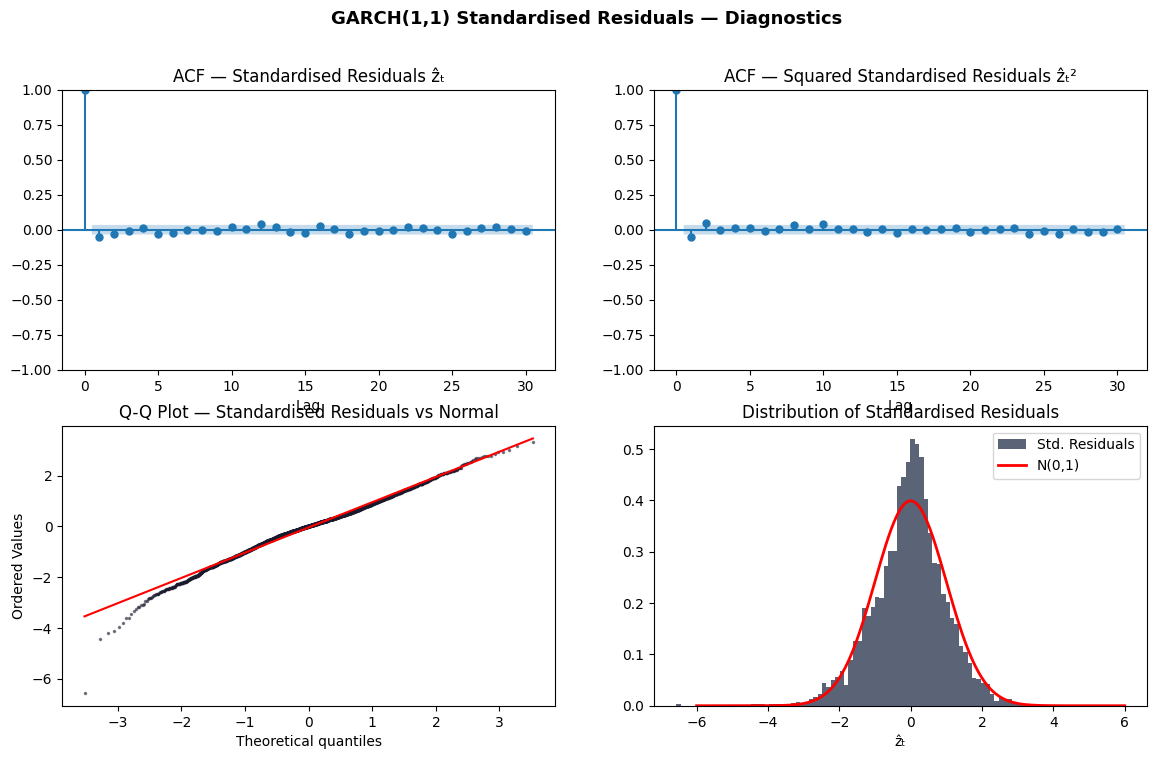

In [20]:
standard_residual = garch_train.std_resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('GARCH(1,1) Standardised Residuals — Diagnostics', fontsize=13, fontweight='bold')

plot_acf(standard_residual, lags=30, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title('ACF — Standardised Residuals ẑₜ')
axes[0, 0].set_xlabel('Lag')

# ACF of squared standardised residuals
plot_acf(standard_residual**2, lags=30, ax=axes[0, 1], alpha=0.05)
axes[0, 1].set_title('ACF — Squared Standardised Residuals ẑₜ²')
axes[0, 1].set_xlabel('Lag')

# Q-Q plot
ax = axes[1, 0]
stats.probplot(standard_residual, dist='norm', plot=ax)
ax.set_title('Q-Q Plot — Standardised Residuals vs Normal')
ax.get_lines()[0].set(markersize=1.5, alpha=0.5, color='#1a1a2e')
ax.get_lines()[1].set(color='red', linewidth=1.5)

ax = axes[1, 1]
ax.hist(standard_residual, bins=80, density=True, color='#16213e', alpha=0.7, label='Std. Residuals')
x = np.linspace(-6, 6, 300)
ax.plot(x, stats.norm.pdf(x), 'r-', linewidth=2, label='N(0,1)')
ax.set_title('Distribution of Standardised Residuals')
ax.set_xlabel('ẑₜ')
ax.legend()


In [21]:
lb_result = acorr_ljungbox(standard_residual**2, lags=[5, 10, 20], return_df=True)

In [23]:
count = 0
for lag, row in lb_result.iterrows():
    pval = row['lb_pvalue']
    if pval < 0.05:
        count += 1
if count > 0:
    print(f'  Ljung-Box test on ẑₜ²: {count} lags show significant autocorrelation. Remaining ARCH effects')
else:
    print('Ljung-Box test on ẑₜ²: No significant autocorrelation. No remaining ARCH effects')

  Ljung-Box test on ẑₜ²: 3 lags show significant autocorrelation. Remaining ARCH effects


In [24]:
lb_result

,lb_stat,lb_pvalue
5,19.093855,0.001846
10,29.379658,0.001081
20,34.478636,0.023063


In [25]:
models = {
    'GARCH(1,1) Normal': fit_garch(train_data, vol='Garch', dist='normal', p=1, q=1),
    'GARCH(1,2) Normal': fit_garch(train_data, vol='Garch', dist='normal', p=1, q=2),
    'GARCH(2,1) Normal': fit_garch(train_data, vol='Garch', dist='normal', p=2, q=1),
    'GARCH(1,1) t-dist': fit_garch(train_data, vol='Garch', dist='t', p=1, q=1),
    'GJR-GARCH(1,1) Normal': fit_garch(train_data, vol='Garch', dist='normal', p=1, q=1, o=1),
    'EGARCH(1,1) Normal': fit_garch(train_data, vol='EGarch', dist='normal', p=1, q=1),
}


def model_result():
    params_dict = {}
    diagnostics_dict = {}
    standard_residual = {}
    for name, result in models.items():
        standard_residual[name] = result.std_resid.dropna()
        lb  = acorr_ljungbox(result.std_resid**2, lags=[5, 10, 20], return_df=True)

        params = result.params
        params_dict[name] = {
            'mu': params.get('mu', np.nan),
            'omega': params.get('omega', np.nan),
            'alpha': params.get('alpha[1]', np.nan),
            'beta': params.get('beta[1]', np.nan),
            'persistence': params.get('alpha[1]', 0) + params.get('beta[1]', 0),
        }

        diagnostics_dict[name] = {
            'LogLikelihood': round(result.loglikelihood, 2),
            'AIC': round(result.aic, 2),
            'BIC': round(result.bic, 2),
            'Lag 5 p-value': round(lb.loc[5, 'lb_pvalue'], 4),
            'Lag 10 p-value': round(lb.loc[10, 'lb_pvalue'], 4),
            'Lag 20 p-value': round(lb.loc[20, 'lb_pvalue'], 4),
        }

    params_df = pd.DataFrame(params_dict).T
    diagnostics_df = pd.DataFrame(diagnostics_dict).T
    return params_df, diagnostics_df, standard_residual

In [33]:
def acf_after_garch(standard_residual):
    fig, axes = plt.subplots(len(standard_residual), 4, figsize=(25, 25), layout='constrained')
    fig.suptitle('GARCH Standardised Residuals — Diagnostics', fontsize=13, fontweight='bold')
    row = 0
    for name, std_resid in standard_residual.items():
        plot_acf(std_resid, lags=30, ax=axes[row, 0], alpha=0.05)
        axes[row, 0].set_title('ACF — Standardised Residuals ẑₜ')
        axes[row, 0].set_xlabel('Lag')

        # ACF of squared standardised residuals
        plot_acf(std_resid**2, lags=30, ax=axes[row, 1], alpha=0.05)
        axes[row, 1].set_title('ACF — Squared Standardised Residuals ẑₜ²')
        axes[row, 1].set_xlabel('Lag')

        # Q-Q plot
        ax = axes[row, 2]
        stats.probplot(std_resid, dist='norm', plot=ax)
        ax.set_title('Q-Q Plot — Standardised Residuals vs Normal')
        ax.get_lines()[0].set(markersize=1.5, alpha=0.5, color='#1a1a2e')
        ax.get_lines()[1].set(color='red', linewidth=1.5)

        ax = axes[row, 3]
        ax.hist(std_resid, bins=80, density=True, color='#16213e', alpha=0.7, label='Std. Residuals')
        x = np.linspace(-6, 6, 300)
        ax.plot(x, stats.norm.pdf(x), 'r-', linewidth=2, label='N(0,1)')
        ax.set_title('Distribution of Standardised Residuals')
        ax.set_xlabel('ẑₜ')
        ax.legend()

        row += 1

In [27]:
params_df, diagnostics_df, standard_residual = model_result()

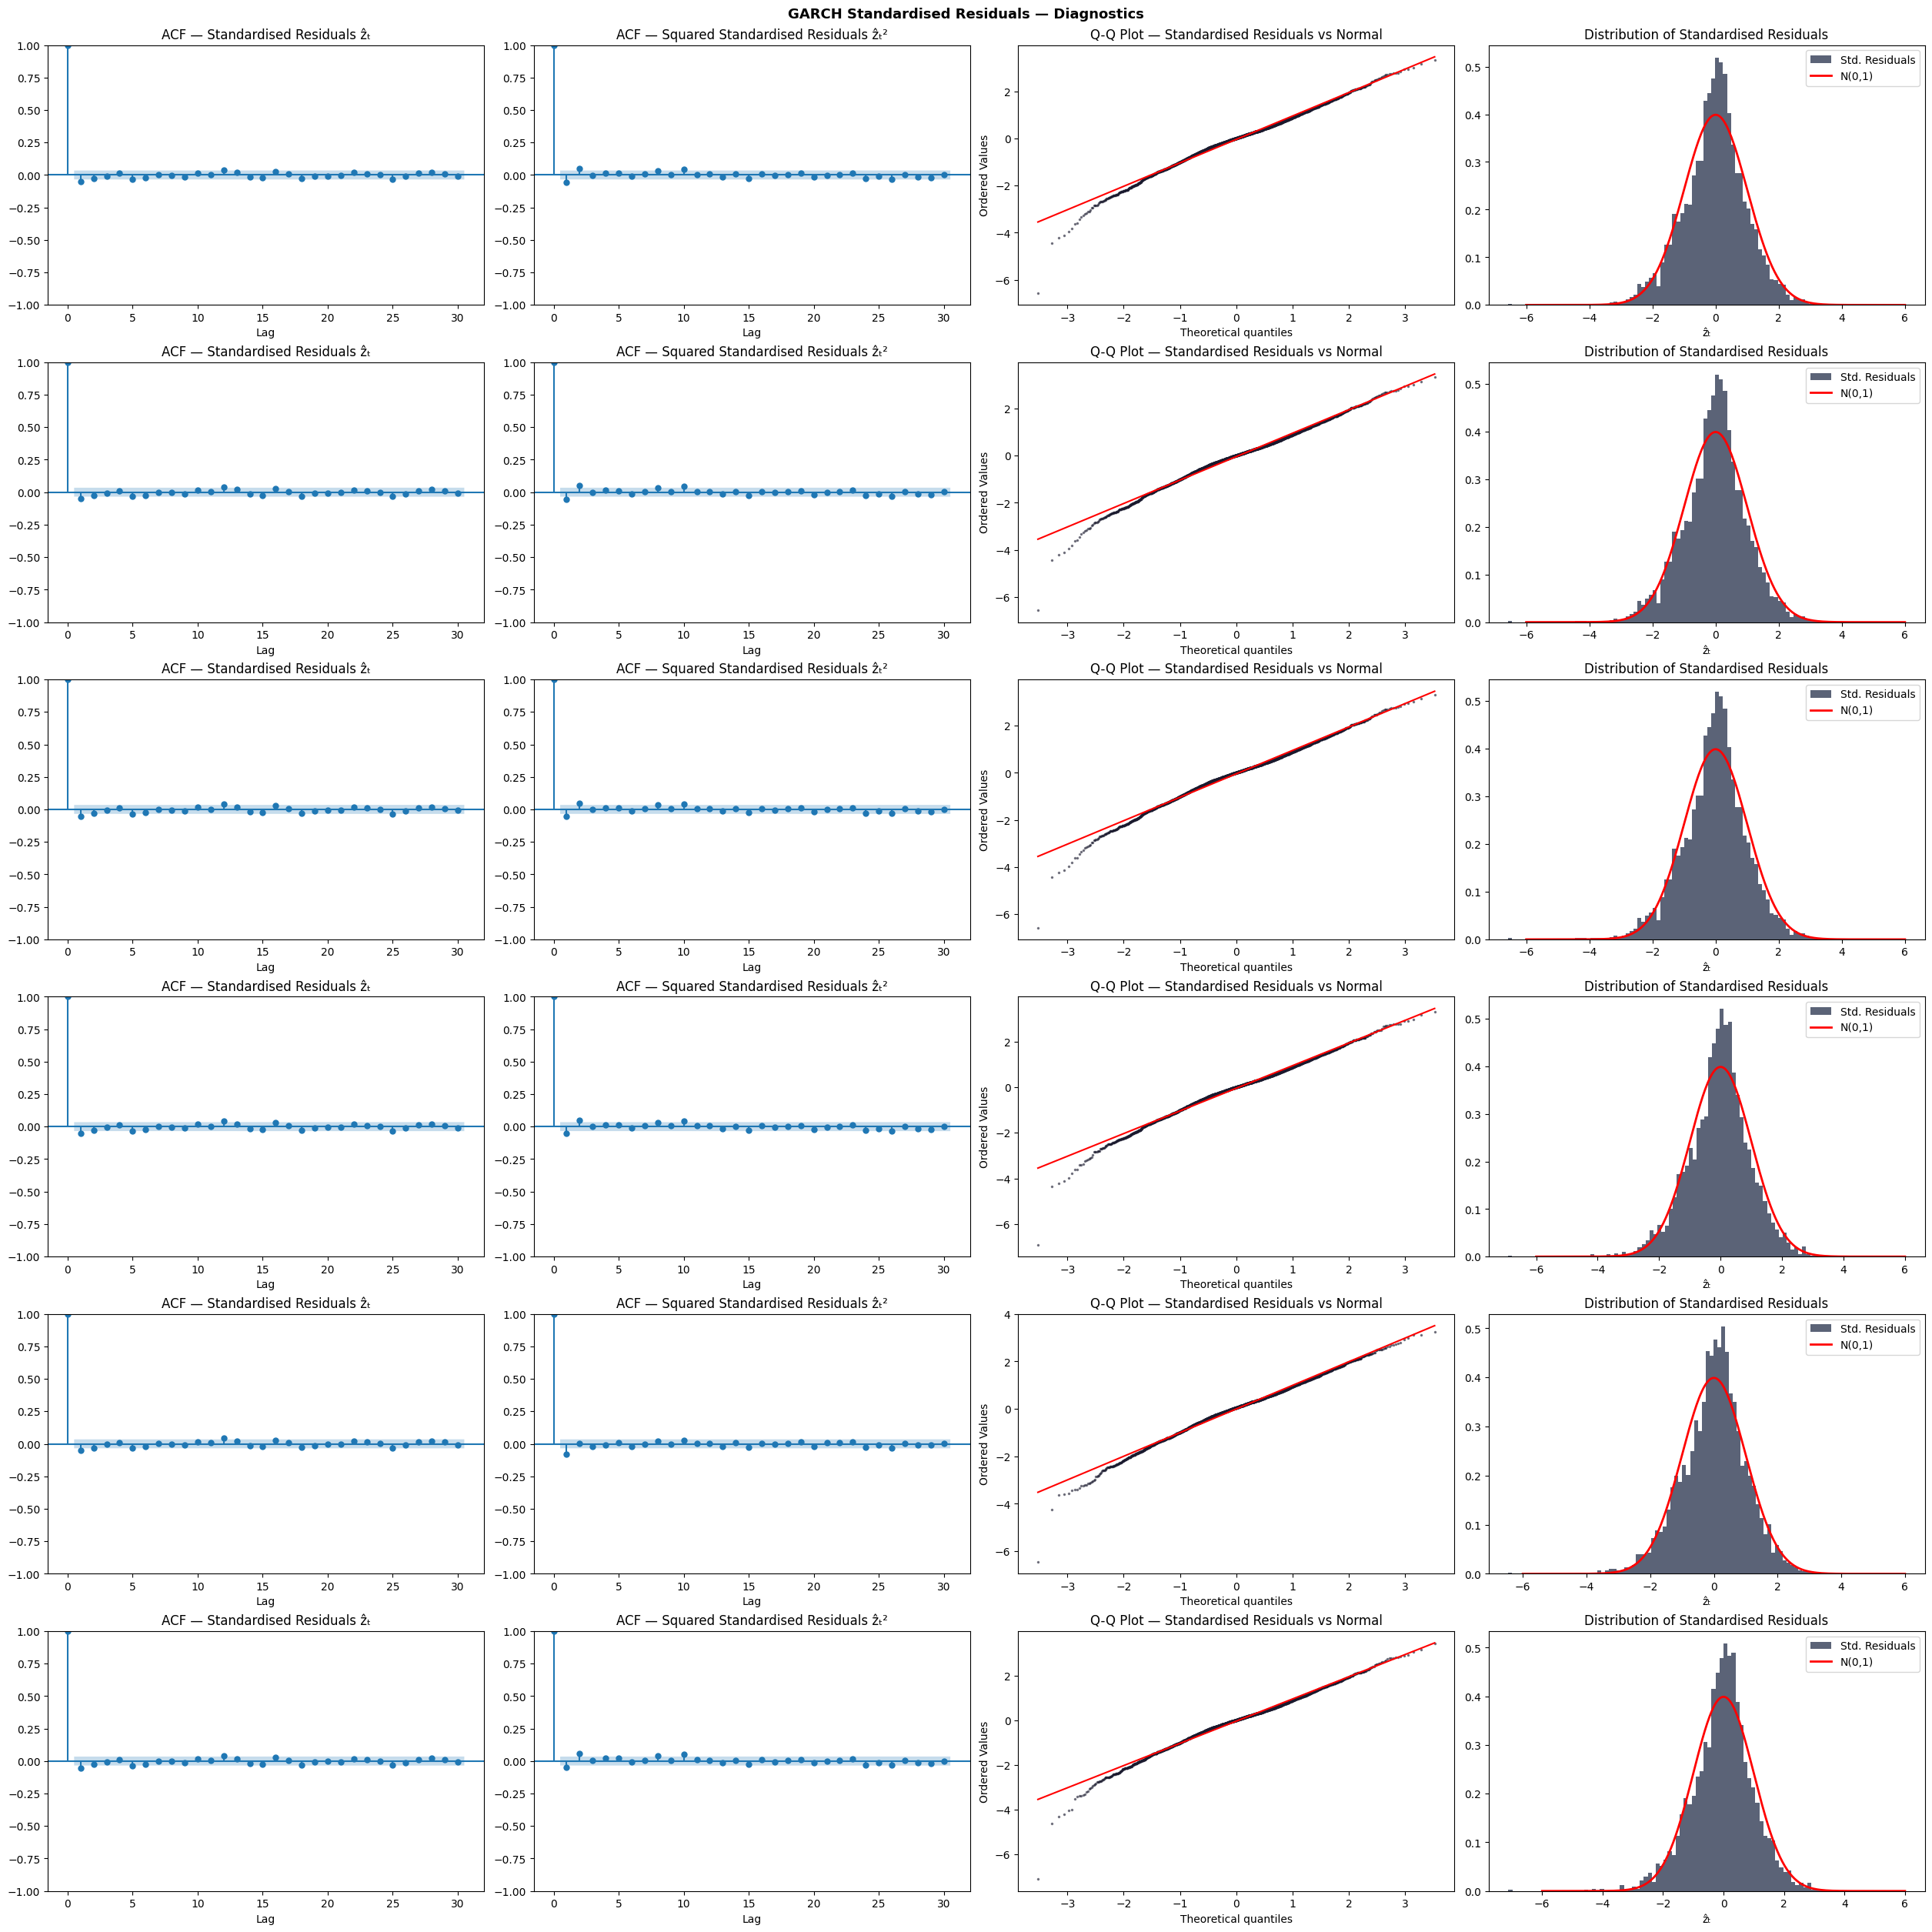

In [34]:
acf_after_garch(standard_residual)

In [24]:
diagnostics_df

,LogLikelihood,AIC,BIC,Lag 5 p-value,Lag 10 p-value,Lag 20 p-value
"GARCH(1,1) Normal",-4873.83,9755.67,9780.04,0.0018,0.0011,0.0231
"GARCH(1,2) Normal",-4873.83,9755.67,9780.04,0.0018,0.0011,0.0231
"GARCH(2,1) Normal",-4873.83,9755.67,9780.04,0.0018,0.0011,0.0231
"GARCH(1,1) t-dist",-4833.76,9677.51,9707.97,0.0031,0.0022,0.0310
"GJR-GARCH(1,1) Normal",-4798.78,9607.55,9638.01,0.0003,0.0015,0.0228
"EGARCH(1,1) Normal",-4884.83,9777.67,9802.03,0.0007,0.0001,0.0073
